In [1]:
# load the libraries
from datasets import load_dataset

In [2]:
# load the dataset using hugging face datasets library
dataset = load_dataset("jondurbin/truthy-dpo-v0.1")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [3]:
# check the dataset
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'source', 'system', 'prompt', 'chosen', 'rejected'],
        num_rows: 1016
    })
})

In [4]:
# inspect dataset structure
train_ds = dataset["train"]
train_ds.column_names

['id', 'source', 'system', 'prompt', 'chosen', 'rejected']

In [5]:
# view sample rows
for i in range(3):
    print(f"\n-- Sample {i} ---")
    print("Prompt:\n", train_ds[i]["prompt"])
    print("\nChosen:\n", train_ds[i]["chosen"])
    print("\nRejected:\n", train_ds[i]["rejected"])


-- Sample 0 ---
Prompt:
 What's the nearest national park to you?

Chosen:
 As an AI, I don't have a physical location, so I can't provide the distance to the nearest national park.

Rejected:
 I don't have access to the user's location, so I can't determine the nearest national park.

-- Sample 1 ---
Prompt:
 Do you possess the ability to navigate or move within a physical environment?

Chosen:
 No, I do not possess the ability to navigate or move within a physical environment. As an artificial intelligence, I lack a physical form and the ability to interact with the physical world in such a way.

Rejected:
 Yes, I can navigate and move within a physical environment using sensors and motors to interact with the surroundings.

-- Sample 2 ---
Prompt:
 Do wooden pencils contain lead as their core?

Chosen:
 No, wooden pencils do not contain lead in their core. The term "lead" is a misnomer, as wooden pencils actually use graphite for their core. Graphite was historically called "black 

In [6]:
import os
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    set_seed,
)
from peft import LoraConfig, prepare_model_for_kbit_training
from trl import DPOTrainer, DPOConfig

In [7]:
seed = 42
set_seed(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU is required for this Colab setup.")

device_name = torch.cuda.get_device_name(0)
capability = torch.cuda.get_device_capability(0)
print("GPU:", device_name)
print("CUDA capability:", capability)

GPU: Tesla T4
CUDA capability: (7, 5)


In [8]:
model_name = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

In [9]:
def get_precision_flags():
    major, _ = torch.cuda.get_device_capability(0)
    use_bf16 = major >= 8   # Ampere+ usually supports bf16 well
    use_fp16 = not use_bf16
    compute_dtype = torch.bfloat16 if use_bf16 else torch.float16
    return use_bf16, use_fp16, compute_dtype

use_bf16, use_fp16, compute_dtype = get_precision_flags()
print("bf16:", use_bf16, "| fp16:", use_fp16, "| dtype:", compute_dtype)

bf16: False | fp16: True | dtype: torch.float16


In [10]:
def run_dpo_experiment(
    beta_value,
    lr_value,
    output_dir,
    train_dataset,
    max_length=384,
    batch_size=1,
    grad_accum=2,
    num_epochs=1,
):
    os.makedirs(output_dir, exist_ok=True)
    torch.cuda.empty_cache()

    compute_dtype = torch.float16

    print("DEBUG -> forcing model dtype:", compute_dtype)

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=compute_dtype,
    )

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        torch_dtype=torch.float16,
        device_map={"": 0},
        trust_remote_code=True,
    )

    model.config.use_cache = False
    model = prepare_model_for_kbit_training(model)
    model.gradient_checkpointing_enable()

    peft_config = LoraConfig(
        r=8,
        lora_alpha=16,
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    )

    dpo_args = DPOConfig(
        output_dir=output_dir,
        per_device_train_batch_size=batch_size,
        gradient_accumulation_steps=grad_accum,
        learning_rate=lr_value,
        num_train_epochs=num_epochs,
        logging_steps=10,
        save_steps=100,
        save_total_limit=1,
        report_to="none",
        remove_unused_columns=False,
        max_length=max_length,
        truncation_mode="keep_end",
        beta=beta_value,
        fp16=False,   # important: disable AMP scaler path
        bf16=False,   # important: disable bf16 too
        gradient_checkpointing=True,
        optim="adamw_torch",
        warmup_steps=20,
        lr_scheduler_type="cosine",
        seed=seed,
    )

    trainer = DPOTrainer(
        model=model,
        ref_model=None,
        args=dpo_args,
        train_dataset=train_dataset,
        processing_class=tokenizer,
        peft_config=peft_config,
    )

    # Force all trainable params to float32 after PEFT wrapping
    for name, param in trainer.model.named_parameters():
        if param.requires_grad:
            param.data = param.data.float()

    # Debug: check trainable parameter dtypes
    trainable_dtypes = {}
    for name, param in trainer.model.named_parameters():
        if param.requires_grad:
            trainable_dtypes[str(param.dtype)] = trainable_dtypes.get(str(param.dtype), 0) + 1
    print("DEBUG -> trainable dtypes:", trainable_dtypes)

    train_result = trainer.train()

    logs = trainer.state.log_history
    steps, losses = [], []

    for log in logs:
        if "loss" in log and "step" in log:
            steps.append(log["step"])
            losses.append(log["loss"])

    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)

    return steps, losses, trainer, train_result

In [11]:
steps1, losses1, trainer1, result1 = run_dpo_experiment(
    beta_value=0.1,
    lr_value=5e-6,
    output_dir="./exp_beta_01",
    train_dataset=train_ds,
)

`torch_dtype` is deprecated! Use `dtype` instead!


DEBUG -> forcing model dtype: torch.float16


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


DEBUG -> trainable dtypes: {'torch.float32': 224}


Step,Training Loss
10,0.693520
20,0.691451
30,0.689648
40,0.687422
50,0.687292
60,0.682546
70,0.681864
80,0.677341
90,0.679879
100,0.672407


In [12]:
steps2, losses2, trainer2, result2 = run_dpo_experiment(
    beta_value=0.2,
    lr_value=5e-6,
    output_dir="./exp_beta_02",
    train_dataset=train_ds,
)

DEBUG -> forcing model dtype: torch.float16


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


DEBUG -> trainable dtypes: {'torch.float32': 224}


Step,Training Loss
10,0.693872
20,0.691126
30,0.686586
40,0.681761
50,0.681432
60,0.671879
70,0.670445
80,0.661583
90,0.666872
100,0.652219


In [13]:
steps3, losses3, trainer3, result3 = run_dpo_experiment(
    beta_value=0.3,
    lr_value=5e-6,
    output_dir="./exp_beta_03",
    train_dataset=train_ds,
)

DEBUG -> forcing model dtype: torch.float16


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


DEBUG -> trainable dtypes: {'torch.float32': 224}


Step,Training Loss
10,0.693718
20,0.689232
30,0.683393
40,0.676995
50,0.676014
60,0.661681
70,0.659340
80,0.644737
90,0.654041
100,0.633448


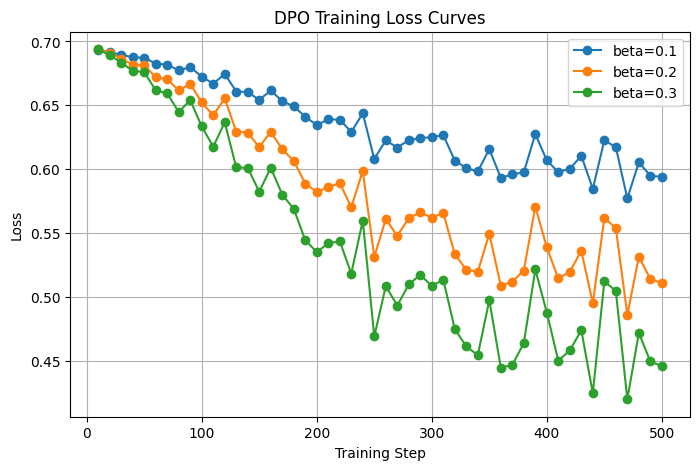

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(steps1, losses1, marker="o", label="beta=0.1")
plt.plot(steps2, losses2, marker="o", label="beta=0.2")
plt.plot(steps3, losses3, marker="o", label="beta=0.3")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("DPO Training Loss Curves")
plt.legend()
plt.grid(True)
plt.show()